**Lab 3**

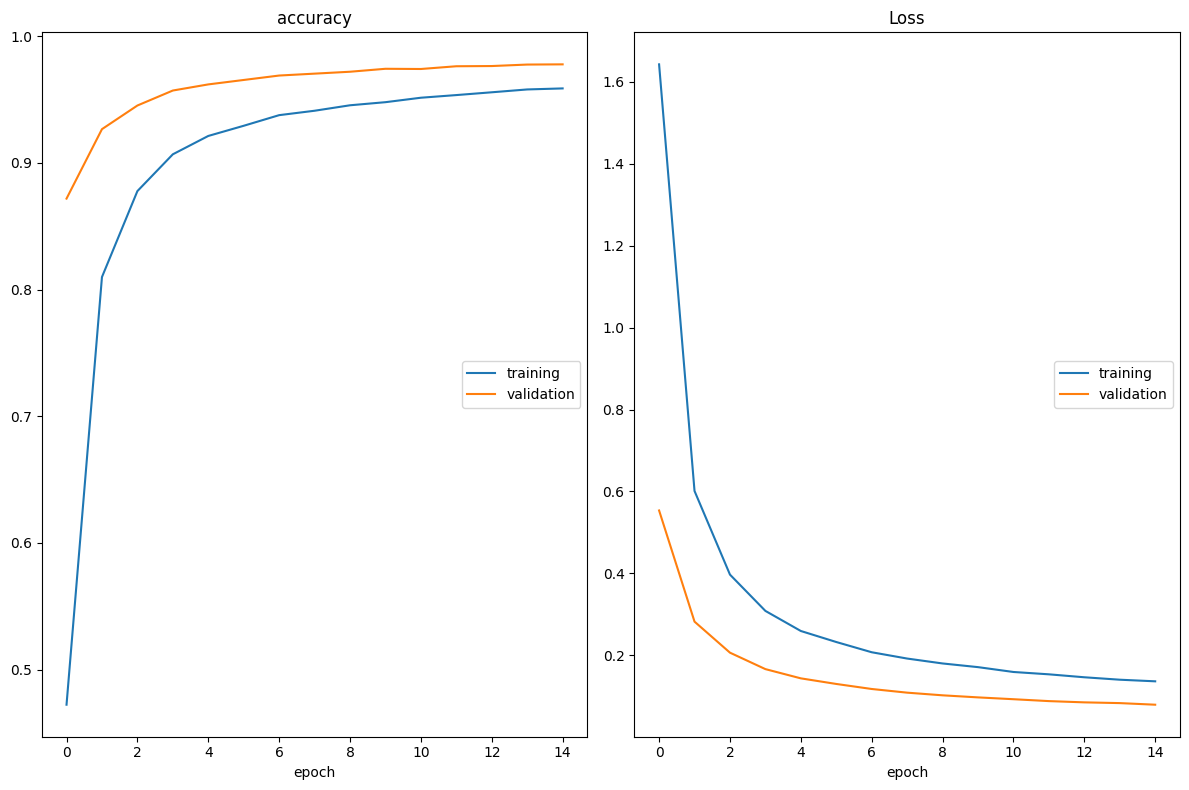

accuracy
	training         	 (min:    0.472, max:    0.959, cur:    0.959)
	validation       	 (min:    0.872, max:    0.978, cur:    0.978)
Loss
	training         	 (min:    0.137, max:    1.643, cur:    0.137)
	validation       	 (min:    0.079, max:    0.554, cur:    0.079)
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.9588 - loss: 0.1365 - val_accuracy: 0.9778 - val_loss: 0.0794
Test loss: 0.08499117940664291
Test accuracy: 0.9746999740600586


In [1]:
#https://keras.io/examples/vision/mnist_convnet/

import numpy as np
import keras
from keras import layers

#dodatkowe pakiety
!pip install livelossplot
from livelossplot import PlotLossesKeras

# callbacks = [PlotLosseesKeras()]
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

batch_size = 128
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="SGD", metrics=["accuracy"])

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, callbacks = [PlotLossesKeras()])

score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

In [2]:
predict = model.predict(x_test)
classes_predicted = np.argmax(predict, axis = 1)
classes = np.argmax(y_test, axis = 1)
confusion_matrix(classes, classes_predicted)
#confusion_matrix(classes, classes_predicted, labels = range(0, 10))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


array([[ 973,    0,    2,    0,    0,    1,    1,    1,    2,    0],
       [   0, 1123,    4,    1,    0,    0,    2,    0,    5,    0],
       [   4,    2, 1003,    2,    3,    0,    0,    9,    9,    0],
       [   1,    0,    3,  988,    0,    2,    0,    8,    8,    0],
       [   1,    2,    3,    0,  965,    0,    3,    1,    2,    5],
       [   2,    1,    1,    9,    1,  867,    5,    1,    4,    1],
       [   9,    3,    0,    0,    3,    2,  937,    0,    4,    0],
       [   0,    5,   23,    4,    0,    0,    0,  986,    4,    6],
       [   8,    0,    5,    4,    3,    1,    2,    4,  936,   11],
       [   4,    6,    1,    8,    5,    5,    0,    6,    5,  969]])

1429 1901 3850 3869 4823


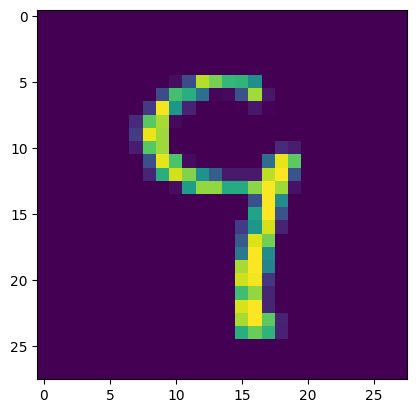

In [3]:
etykiety = []
for idx in range(0, len(classes)):
  if (classes[idx] == 9) and (classes_predicted[idx] == 4):
    etykiety.append(idx)

print(*etykiety)
plt.imshow(x_test[1192, :, :])

Konwolucyjna sieć

In [4]:
inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(inputs)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model_no_max_pool = keras.Model(inputs=inputs, outputs=outputs)
model_no_max_pool.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,234 (1.42 MB)

 Trainable params: 372,234 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

**Lab 4**

Dataset: BloodMINST